In [2]:
import re
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Extracting the data from Website
cars =[]
final_links=[]
name = []
model = []
price = []
location = []
owner = []
date =[]
engine_type =[]
total_trip = []
transmission = []
varient = []
for i in range(1,11):
        url = f'https://www.olx.in/bengaluru_g4058803/cars_c84?page={i}'
        header ={
                'user-agent': "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/139.0.0.0 Safari/537.36 OPR/123.0.0.0"}
        page = requests.get(url,headers=header)
        print(page.status_code)
        soup = BeautifulSoup(page.text,'html.parser')
        for i in soup.find_all('li', class_='_3V_Ww'):
            link_tag = i.find('a', class_='')
            if link_tag:
                prod_link = link_tag.get('href')
                final_prod_link = 'https://www.olx.in' + prod_link
                final_links.append(final_prod_link)
            else:
                print("Link tag not found")
for url in final_links:
    final_page = requests.get(url,headers=header)
    f_soup = BeautifulSoup(final_page.text,'html.parser')
    prod_name_tag = f_soup.find('h1', class_='_2iMMO')
    if prod_name_tag:
            prod_name = prod_name_tag.text
            cars.append(prod_name)
    else:
            cars.append(np.nan)
#for car full name
    car_name_pat =re.findall(r'(\w+.{0,25})\([0-9]{4}\)',prod_name)
    if car_name_pat:
        name.append(car_name_pat[0])
    else:
        name.append(np.nan)
    
                    
#for car model(year)
    car_model_pat = re.findall(r'\w+.{0,25}\(([0-9]{4})\)',prod_name)
    if car_name_pat:
        model.append(car_model_pat[0])
    else:
        model.append(np.nan)
    

#for  price& qwner and location
    car_price_tag = f_soup.find('div',class_='_2_dzo _3UcJr')
    if car_price_tag:
        car_price = car_price_tag.text
        price_pat =re.findall(r'^₹(.+)',car_price)
        if price_pat:
            price.append(price_pat[0])
        else:
            price.append(np.nan)
    else:
        price.append(np.nan)
                    
    
    for k in f_soup.find_all("div",class_="_2mPp9"):
        owner_pat = re.findall(r'Owner([0-9]{1,2})\w{3}',k.text)
        if owner_pat:
            owner.append(owner_pat[0])
        else:
            owner.append(np.nan)
                    
        loc_pat = re.findall(r'Location(\w+\s{0,1}\w+\s{0,1}\w+\s{0,2}\w{0,10}\s{0,1}\w+\,{0,1}\sBengaluruPosting)\s',k.text)
        if loc_pat:
            location.append(loc_pat[0])
        else:
            location.append(np.nan)
    
        posting_date = re.findall(r'date([0-9]{2}\-\w{3}\-[0-9]{2})',k.text)
        if posting_date:
            date.append(posting_date[0])
        else:
            date.append(np.nan)

                    
    for k in f_soup.find_all('div',class_='dz6zp'):
        en_type_pat = re.findall(r'([a-zA-Z]+)[0-9]+\,[0-9]+\s[a-zA-Z]+',k.text)
        if en_type_pat:
            engine_type.append(en_type_pat[0])
        else:
            engine_type.append(np.nan)
    
    
        total_trip_pat = re.findall(r'[a-zA-Z]+([0-9]+\,[0-9]+)\s[a-zA-Z]+',k.text)
        if total_trip:
            total_trip.append(total_trip_pat)
        else:
            total_trip.append(np.nan)
    
    
        transmission_pat = re.findall(r'Km(.+)',k.text)
        if transmission_pat:
            transmission.append(transmission_pat[0])
        else:
            transmission.append(np.nan)
                            
    
    varient_tag = f_soup.find('div','BxCeR')
    if varient_tag:
        car_varient = varient_tag.text
        var_pat = re.findall(r'.+',car_varient)
        if var_pat:
            varient.append(var_pat[0])
        else:
            varient.append(np.nan)
    else:
        varient.append(np.nan)
print('page done')

200
200
200
200
200
200
200
200
200
200
page done


In [9]:
print(len(final_links))

399


In [10]:
print(len(name))
print(len(model))
print(len(price))
print(len(location))
print(len(owner))
print(len(date))
print(len(engine_type))
print(len(transmission))
print(len(total_trip))
print(len(varient)) 


399
399
399
399
399
399
399
399
399
399


In [11]:
print(name)

['mitsubishi cedia ', 'bmw 3 series gran limousine ', 'skoda octavia ', 'toyota fortuner ', 'toyota innova ', 'maruti suzuki ritz ', 'hyundai i20 active ', 'mahindra tuv 300 ', 'maruti suzuki brezza ', 'renault kwid ', 'hyundai grand i10 nios ', 'honda city ', 'mahindra tuv 300 ', 'hyundai venue ', 'maruti suzuki swift ', 'ford ecosport ', 'maruti suzuki swift ', 'maruti suzuki swift ', 'jeep compass ', 'kia seltos ', 'maruti suzuki swift ', 'skoda kushaq ', 'hyundai new elantra ', 'ford ecosport ', 'honda jazz ', 'renault kwid ', 'ford fiesta ', 'hyundai verna ', 'hyundai eon ', 'maruti suzuki swift dzire ', 'hyundai creta ', 'mahindra xuv500 ', 'hyundai aura ', 'maruti suzuki celerio ', 'hyundai grand i10 ', 'hyundai i20 ', 'mahindra kuv 100 ', 'maruti suzuki wagon r 1.0 ', 'honda jazz ', 'hyundai grand i10 nios ', 'maruti suzuki baleno ', 'maruti suzuki swift dzire ', 'toyota fortuner legender ', 'honda brio ', 'maruti suzuki ciaz ', 'hyundai aura ', 'honda brio ', 'maruti suzuki al

In [12]:
print(model)

['2012', '2021', '2016', '2021', '2008', '2012', '2016', '2019', '2020', '2016', '2022', '2015', '2017', '2022', '2014', '2017', '2012', '2022', '2017', '2020', '2018', '2024', '2013', '2014', '2015', '2015', '2010', '2012', '2012', '2010', '2021', '2015', '2021', '2014', '2013', '2013', '2016', '2018', '2019', '2020', '2017', '2022', '2023', '2013', '2016', '2020', '2014', '2020', '2022', '2021', '2018', '2020', '2016', '2013', '2016', '2013', '2016', '2011', '2022', '2015', '2016', '2012', '2016', '2014', '2017', '2020', '2015', '2019', '2020', '2013', '2017', '2021', '2013', '2015', '2016', '2017', '2017', '2021', '2016', '2015', '2012', '2010', '2017', '2016', '2020', '2007', '2012', '2015', '2008', '2015', '2021', '2023', '2020', '2016', '2016', '2023', '2017', '2018', '2012', '2006', '2011', '2017', '2013', '2016', '2012', '2021', '2017', '2016', '2023', '2015', '2018', '2018', '2017', '2021', '2014', '2021', '2009', '2018', '2020', '2008', '2013', '2014', '2021', '2015', '2015',

In [13]:
print(price)

[' 11,00,000', ' 41,50,000', ' 8,95,000', ' 34,50,000', ' 5,65,000', ' 3,50,000', ' 4,79,055', ' 6,35,000', ' 8,90,000', ' 2,56,000', ' 6,25,000', ' 6,39,731', ' 5,99,716', ' 8,63,238', ' 4,55,000', ' 6,55,000', ' 4,18,000', ' 7,65,000', ' 10,85,000', ' 9,15,000', ' 6,10,000', ' 13,50,000', ' 5,25,000', ' 4,24,000', ' 3,29,801', ' 2,20,000', ' 2,60,000', ' 5,35,000', ' 2,45,000', ' 3,35,000', ' 16,75,000', ' 10,90,000', ' 6,51,847', ' 3,18,825', ' 2,90,000', ' 3,99,000', ' 3,16,000', ' 3,69,000', ' 7,75,000', ' 5,19,000', ' 6,25,000', ' 8,00,000', ' 46,95,000', ' 2,73,000', ' 4,48,000', ' 5,19,000', ' 3,28,000', ' 2,86,000', ' 12,00,000', ' 5,45,000', ' 6,70,000', ' 7,00,000', ' 6,20,000', ' 6,00,000', ' 5,70,000', ' 3,75,000', ' 5,50,000', ' 2,25,000', ' 23,00,000', ' 4,95,000', ' 22,96,000', ' 1,80,000', ' 4,85,000', ' 4,50,000', ' 5,75,000', ' 19,99,999', ' 5,35,000', ' 27,00,000', ' 4,00,000', ' 3,60,000', ' 4,10,000', ' 15,75,000', ' 3,10,000', ' 3,49,000', ' 6,30,000', ' 6,75,000

In [14]:
print(location)

['Rajaji Nagar, BengaluruPosting', 'Banashankari Stage 2, BengaluruPosting', 'RK Layout 2nd Stage, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Kamakshipalya, BengaluruPosting', 'Rajaji Nagar, BengaluruPosting', 'Cholurpalya, BengaluruPosting', 'Cholurpalya, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Gandhi Nagar, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Cholurpalya, BengaluruPosting', 'Gandhi Nagar, BengaluruPosting', 'Cholurpalya, BengaluruPosting', 'Shastri Nagar, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Kamakshipalya, BengaluruPosting', 'Kamakshipalya, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Vijaya Nagar, BengaluruPosting', 'Banashankari, BengaluruPosting', 'Chamarajpet, BengaluruPosting', 'Gandhi Nagar, BengaluruPosting', 'Gandhi Nagar, BengaluruPosting', 'Gandhi Nagar, BengaluruPosting', 'Banashankari Stage 1, BengaluruPosting', 'Jaya Nagar East, BengaluruPosting', 'Jaya Nagar East, Beng

In [15]:
print(owner)

['4', '1', '3', '1', '3', '2', '2', '2', '1', '1', '1', '1', '3', '1', '1', '2', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2', '1', '1', '2', '1', '1', '1', '2', '2', '2', '2', '2', '1', '1', '2', '1', '2', '1', '2', '1', '2', '1', '2', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2', '1', '2', '1', '4', '1', '2', '2', '2', '3', '2', '2', '1', '1', '1', '2', '1', '1', '1', '1', '1', '1', '1', '3', '2', '1', '2', '1', '2', '2', '4', '1', '1', '1', '1', '1', '2', '1', '1', '1', '2', '2', '2', '2', '1', '1', '1', '2', '1', '2', '3', '1', '1', '2', '1', '2', '1', '1', '1', '2', '1', '1', '2', '2', '1', '1', '1', '1', '1', '1', '2', '3', '2', '1', '1', '2', '1', '1', '2', '1', '1', '1', '1', '1', '1', '2', '1', '2', '1', '1', '2', '3', nan, '1', '4', '1', '1', '1', '2', '2', '1', '1', '2', '1', '1', '2', '1', '1', '1', '1', '2', '1', '2', '2', '2', '3', '2', '2', '1', '2', '2', '1', '1', '3', '1', '2', '1', '2', '1', '2', '2', '2', '2', '2', '1', '2', '3', '1', '1', '2', '2', '1', '1',

In [16]:
print(date)

['05-NOV-25', '08-NOV-25', '22-OCT-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '16-NOV-25', '16-NOV-25', '15-NOV-25', '16-NOV-25', '15-NOV-25', '16-NOV-25', '16-NOV-25', '16-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '10-NOV-25', '03-NOV-25', '07-NOV-25', '16-NOV-25', '16-NOV-25', '16-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '16-NOV-25', '16-NOV-25', '16-NOV-25', '15-NOV-25', '16-NOV-25', '16-NOV-25', '15-NOV-25', '16-NOV-25', '29-OCT-25', '25-OCT-25', '06-OCT-25', '16-NOV-25', '16-NOV-25', '16-NOV-25', '16-NOV-25', '16-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '10-NOV-25', '08-NOV-25', '10-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25', '16-NOV-25', '15-NOV-25', '15-NOV-25', '15-NOV-25'

In [17]:
print(engine_type)

['Petrol', 'Diesel', 'Petrol', 'Diesel', 'Diesel', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Hybrids', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Diesel', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol'

In [18]:
print(transmission)

['Manual', 'Automatic', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Manual', 'Automatic', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Automatic', 'Manual', 'Manual', 'Automatic', 'Automatic', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Automatic', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Automatic', 'Automatic', 'Automatic', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Automatic', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Automatic', 'Manual

In [19]:
print(varient)

['New Sports', '2.0 320Ld Luxury Line', '[2017-2018] 1.8 Style Plus TSI AT', '4X2 AT 2.8 Diesel', '[2013-2016] 2.5 V Diesel 8 STR', 'Vdi BS-IV', '1.2 S', '1.5 T10', '1.5 ZXI AT SMART HYBRID DUAL TONE', '2015-2019 0.8 RXT', 'Corporate Edition 1.2 VTVT', '2014-2015 i VTEC CVT VX', '1.5 T8', '1.2 S (O)', '2011-2014 VDI', '1.5 Titanium Plus TI-VCT AT', '2011-2017 VDI', '1.2 ZXI AMT Plus', '2.0 Longitude (O) Diesel', '1.5 HTK Petrol', '2018-2021 1.2 VXI AMT', '1.0 TSI Ambition AT', '1.8 SX MT VTVT', '[2013-2015] 1.5 Titanium TDCI', '[2015-2018] 1.2 S i VTEC', '2015-2019 0.8 RXT', '2008-2011 1.4 ZXi TDCi ABS', '[2011-2015] FLUIDIC 1.6 CRDi SX', 'Era +', '2008-2012 1.2 VXI', 'SX (O) 1.5 Diesel Automatic', '2.2 W10 AWD', '[2020-2023] 1.2 SX Plus Petrol AMT', '2014-2017 1.0 VXI AT', '1.1 CRDi Sportz', '1.2 Spotz', '[2015-2017] 1.2 K6 5 Str', '2006-2010 1.0 VXi', '1.2 VX CVT i-VTEC', '1.2 Kappa VTVT Sportz AMT', '2015-2019 1.2 Zeta AT', 'ZXI + AMT', '4X2 AT 2.8 Legender', '[2011-2013] 1.2 V MT',

In [20]:
print(total_trip)

[nan, ['560,003'], ['5,500'], ['77,000'], ['221,000'], ['65,000'], ['50,846'], ['46,232'], ['64,000'], ['69,005'], ['23,000'], ['35,906'], ['65,765'], ['3,759'], ['60,000'], ['48,810'], ['723,310'], ['73,310'], ['80,000'], ['56,000'], ['15,000'], ['9,000'], ['74,258'], ['57,471'], ['102,306'], ['75,750'], ['76,000'], ['76,000'], ['43,000'], ['103,000'], ['60,000'], ['53,000'], ['26,881'], ['38,036'], ['67,234'], ['86,000'], ['27,837'], ['50,824'], ['20,000'], ['38,438'], ['74,000'], ['17,000'], ['16,000'], ['119,328'], ['102,535'], ['61,882'], ['62,395'], ['22,676'], ['66,480'], ['27,000'], ['18,000'], ['82,000'], ['89,000'], ['88,000'], ['51,000'], ['68,000'], ['62,000'], ['73,000'], ['47,121'], ['95,741'], ['36,000'], ['95,000'], ['35,000'], ['86,231'], ['160,000'], ['110,000'], ['73,000'], ['36,000'], ['98,000'], ['59,000'], ['89,000'], ['33,572'], ['98,000'], ['96,630'], ['80,000'], ['64,000'], ['162,000'], ['29,000'], ['87,000'], ['39,000'], ['78,000'], ['78,000'], ['205,000'], ['

In [21]:
print(len(name))
print(len(model))
print(len(price))
print(len(location))
print(len(owner))
print(len(date))
print(len(engine_type))
print(len(transmission))
print(len(total_trip))
print(len(varient)) 


399
399
399
399
399
399
399
399
399
399


In [22]:
data ={
    'Car_Name':name,
    'Model_Year':model,
    'Price':price,
    'Location':location,
    'Owner':owner,
    'Posting_Date':date,
    'Engine_Type':engine_type,
    'Transmission':transmission,
    'Varient':varient,
    'Total_trip':total_trip, 
}

In [23]:
df = pd.DataFrame(data)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_Name      399 non-null    object 
 1   Model_Year    399 non-null    int64  
 2   Price         399 non-null    object 
 3   Location      399 non-null    object 
 4   Owner         396 non-null    float64
 5   Posting_Date  399 non-null    object 
 6   Engine_Type   399 non-null    object 
 7   Transmission  399 non-null    object 
 8   Varient       396 non-null    object 
 9   Total_trip    398 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 31.3+ KB


In [26]:
# importing the dataFrame into csv
df.to_csv('Car_data.csv',index=False)

In [27]:
df = pd.read_csv('Car_data.csv')

In [28]:
df

,Car_Name,Model_Year,Price,Location,Owner,Posting_Date,Engine_Type,Transmission,Varient,Total_trip
0,mitsubishi cedia,2012,"11,00,000","Rajaji Nagar, BengaluruPosting",4.0,05-NOV-25,Petrol,Manual,New Sports,NaN
1,bmw 3 series gran limousine,2021,"41,50,000","Banashankari Stage 2, BengaluruPosting",1.0,08-NOV-25,Diesel,Automatic,2.0 320Ld Luxury Line,"['560,003']"
2,skoda octavia,2016,"8,95,000","RK Layout 2nd Stage, BengaluruPosting",3.0,22-OCT-25,Petrol,Automatic,[2017-2018] 1.8 Style Plus TSI AT,"['5,500']"
3,toyota fortuner,2021,"34,50,000","Banashankari, BengaluruPosting",1.0,15-NOV-25,Diesel,Manual,4X2 AT 2.8 Diesel,"['77,000']"
4,toyota innova,2008,"5,65,000","Kamakshipalya, BengaluruPosting",3.0,15-NOV-25,Diesel,Manual,[2013-2016] 2.5 V Diesel 8 STR,"['221,000']"
...,...,...,...,...,...,...,...,...,...,...
394,maruti suzuki s-cross,2020,"8,25,000","Banashankari, BengaluruPosting",2.0,15-NOV-25,Diesel,Manual,2017-2020 1.3 Delta,"['122,317']"
395,bmw 5 series,2019,"48,00,000","Sadashiva Nagar, BengaluruPosting",1.0,15-NOV-25,Diesel,Automatic,3.0 530D M Sport,"['45,060']"
396,tata tiago,2017,"3,00,000","Govindhaiah Layout, BengaluruPosting",2.0,15-NOV-25,Petrol,Manual,[2016-2020] 1.2 Revotron XT,"['117,606']"
397,hyundai grand i10,2016,"5,27,000","Vijaya Nagar, BengaluruPosting",1.0,15-NOV-25,Petrol,Automatic,[2013-2017] 1.2 Kappa Asta VTVT,"['30,000']"


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Car_Name      399 non-null    object        
 1   Model_Year    399 non-null    int64         
 2   Price         399 non-null    int64         
 3   Location      399 non-null    object        
 4   Owner         396 non-null    Int64         
 5   Posting_Date  399 non-null    datetime64[ns]
 6   Engine_Type   399 non-null    object        
 7   Transmission  399 non-null    object        
 8   Varient       396 non-null    object        
 9   Total_trip    398 non-null    Int64         
dtypes: Int64(2), datetime64[ns](1), int64(2), object(5)
memory usage: 32.1+ KB


In [32]:
df.head()

,Car_Name,Model_Year,Price,Location,Owner,Posting_Date,Engine_Type,Transmission,Varient,Total_trip
0,mitsubishi cedia,2012,"11,00,000","Rajaji Nagar, BengaluruPosting",4.0,05-NOV-25,Petrol,Manual,New Sports,NaN
1,bmw 3 series gran limousine,2021,"41,50,000","Banashankari Stage 2, BengaluruPosting",1.0,08-NOV-25,Diesel,Automatic,2.0 320Ld Luxury Line,"['560,003']"
2,skoda octavia,2016,"8,95,000","RK Layout 2nd Stage, BengaluruPosting",3.0,22-OCT-25,Petrol,Automatic,[2017-2018] 1.8 Style Plus TSI AT,"['5,500']"
3,toyota fortuner,2021,"34,50,000","Banashankari, BengaluruPosting",1.0,15-NOV-25,Diesel,Manual,4X2 AT 2.8 Diesel,"['77,000']"
4,toyota innova,2008,"5,65,000","Kamakshipalya, BengaluruPosting",3.0,15-NOV-25,Diesel,Manual,[2013-2016] 2.5 V Diesel 8 STR,"['221,000']"


In [35]:
df.columns

Index(['Car_Name', 'Model_Year', 'Price', 'Location', 'Owner', 'Posting_Date',
       'Engine_Type', 'Transmission', 'Varient', 'Total_trip'],
      dtype='object')

In [44]:
df.dtypes

Car_Name                object
Model_Year               int64
Price                    int64
Location                object
Owner                    Int64
Posting_Date    datetime64[ns]
Engine_Type             object
Transmission            object
Varient                 object
Total_trip               Int64
dtype: object

In [37]:
df['Price'] = df['Price'].str.replace(',', '').astype(int)


In [39]:
df['Owner'] = df['Owner'].astype('Int64')


In [41]:
df['Posting_Date'] = pd.to_datetime(df['Posting_Date'], format="%d-%b-%y")


In [43]:
df['Total_trip'] = df['Total_trip'].str.extract(r"(\d[\d,]*)")[0]
df['Total_trip'] = df['Total_trip'].str.replace(',', '').astype('Int64')


In [46]:
df.isnull().sum()

Car_Name        0
Model_Year      0
Price           0
Location        0
Owner           3
Posting_Date    0
Engine_Type     0
Transmission    0
Varient         3
Total_trip      1
dtype: int64

In [48]:
df['Total_trip'] = df['Total_trip'].fillna(df['Total_trip'].median())

In [58]:
df['Varient'] = df['Varient'].bfill()

In [51]:
df['Owner'] = df['Owner'].bfill()

In [59]:
df.isnull().sum()

Car_Name        0
Model_Year      0
Price           0
Location        0
Owner           0
Posting_Date    0
Engine_Type     0
Transmission    0
Varient         0
Total_trip      0
dtype: int64

In [76]:
df

,Car_Name,Model_Year,Price,Location,Owner,Posting_Date,Engine_Type,Transmission,Varient,Total_trip
0,mitsubishi cedia,2012,1100000,"Rajaji Nagar, BengaluruPosting",4,2025-11-05,Petrol,Manual,New Sports,65000
1,bmw 3 series gran limousine,2021,4150000,"Banashankari Stage 2, BengaluruPosting",1,2025-11-08,Diesel,Automatic,2.0 320Ld Luxury Line,560003
2,skoda octavia,2016,895000,"RK Layout 2nd Stage, BengaluruPosting",3,2025-10-22,Petrol,Automatic,[2017-2018] 1.8 Style Plus TSI AT,5500
3,toyota fortuner,2021,3450000,"Banashankari, BengaluruPosting",1,2025-11-15,Diesel,Manual,4X2 AT 2.8 Diesel,77000
4,toyota innova,2008,565000,"Kamakshipalya, BengaluruPosting",3,2025-11-15,Diesel,Manual,[2013-2016] 2.5 V Diesel 8 STR,221000
...,...,...,...,...,...,...,...,...,...,...
394,maruti suzuki s-cross,2020,825000,"Banashankari, BengaluruPosting",2,2025-11-15,Diesel,Manual,2017-2020 1.3 Delta,122317
395,bmw 5 series,2019,4800000,"Sadashiva Nagar, BengaluruPosting",1,2025-11-15,Diesel,Automatic,3.0 530D M Sport,45060
396,tata tiago,2017,300000,"Govindhaiah Layout, BengaluruPosting",2,2025-11-15,Petrol,Manual,[2016-2020] 1.2 Revotron XT,117606
397,hyundai grand i10,2016,527000,"Vijaya Nagar, BengaluruPosting",1,2025-11-15,Petrol,Automatic,[2013-2017] 1.2 Kappa Asta VTVT,30000


#### Univariate analysis

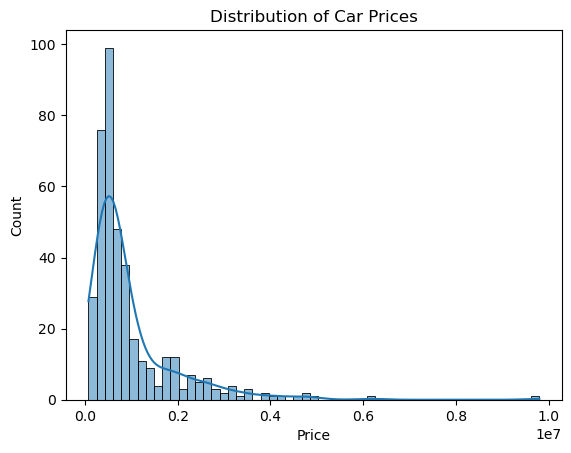

In [67]:
#price distribution
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

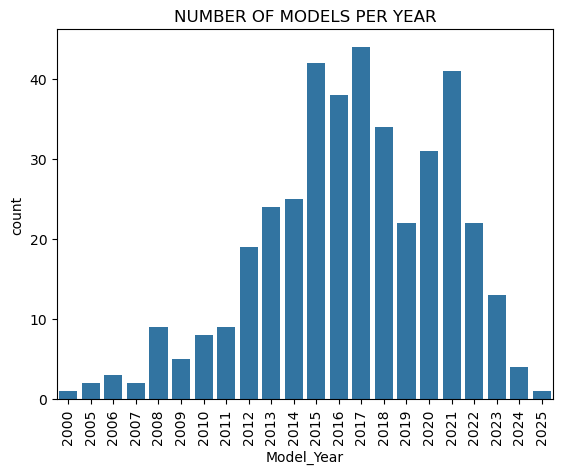

In [90]:
#model year
sns.countplot(x='Model_Year', data=df)
plt.xticks(rotation=90)
plt.title("NUMBER OF MODELS PER YEAR")
plt.show()

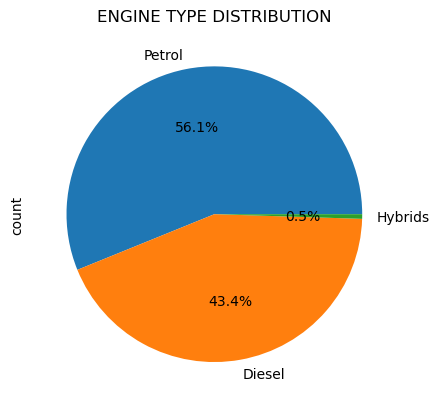

In [91]:
df['Engine_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("ENGINE TYPE DISTRIBUTION")
plt.show()

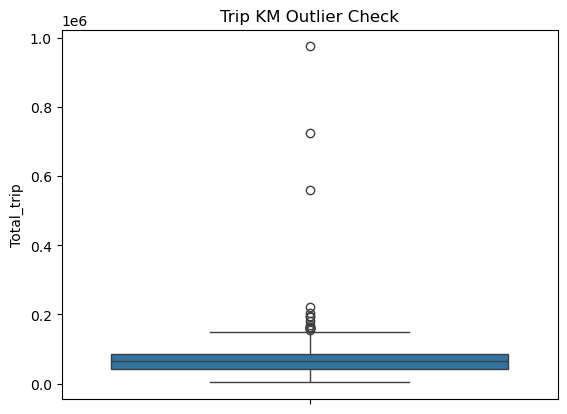

In [75]:
sns.boxplot(df['Total_trip'])
plt.title("Trip KM Outlier Check")
plt.show()

#### Bivariate analysis

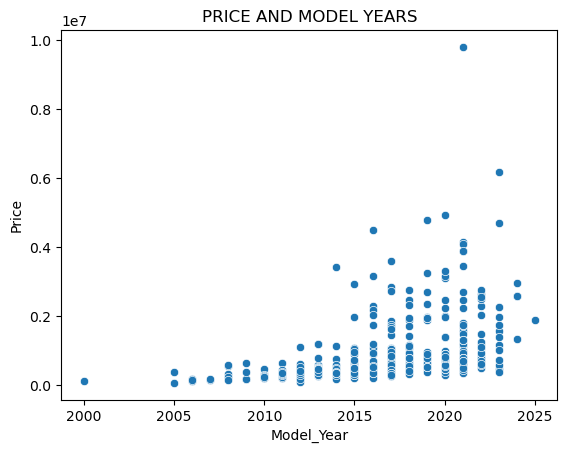

In [92]:
#price vs model year
sns.scatterplot(x='Model_Year', y='Price', data=df)
plt.title("PRICE AND MODEL YEARS")
plt.show()

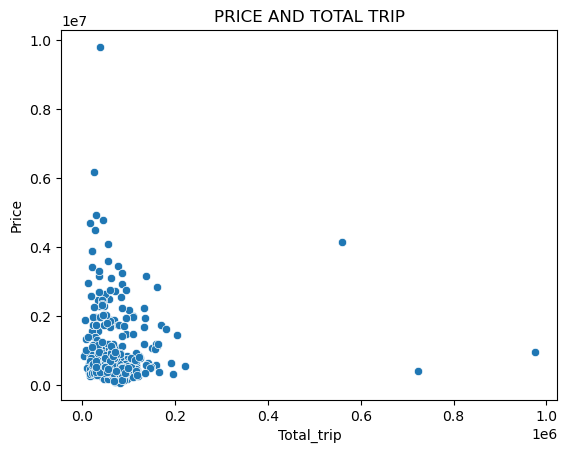

In [93]:
#price vs total trip
sns.scatterplot(x='Total_trip', y='Price', data=df)
plt.title("PRICE AND TOTAL TRIP")
plt.show()

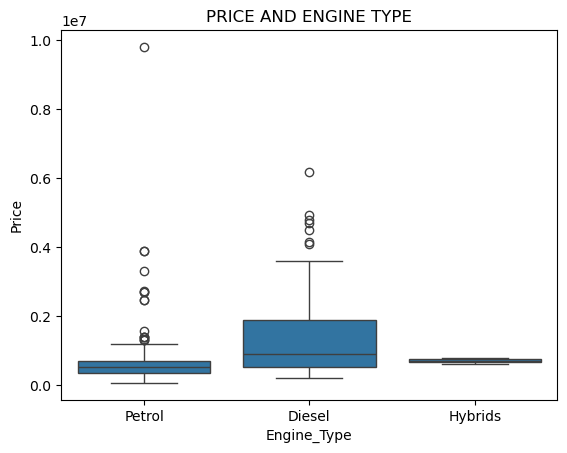

In [94]:
#price vs engine type
sns.boxplot(x='Engine_Type', y='Price', data=df)
plt.title("PRICE AND ENGINE TYPE")
plt.show()

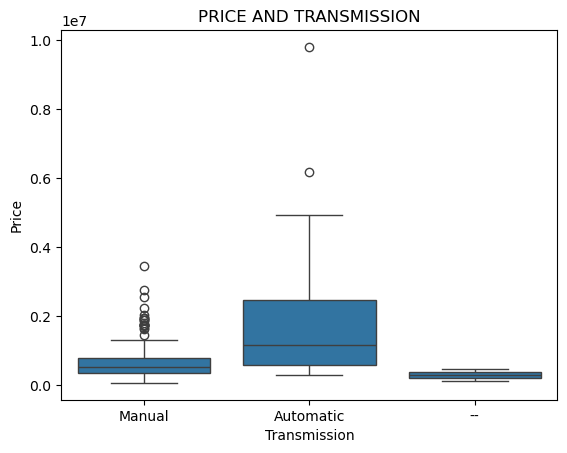

In [95]:
#price vs transmission
sns.boxplot(x='Transmission', y='Price', data=df)
plt.title("PRICE AND TRANSMISSION")
plt.show()

In [84]:
#engin type vs transmission => categorical - categorical
pd.crosstab(df.Engine_Type, df.Transmission)


Transmission,--,Automatic,Manual
Engine_Type,,,
Diesel,1,51,121
Hybrids,0,1,1
Petrol,1,65,158


#### Multivariate analysis

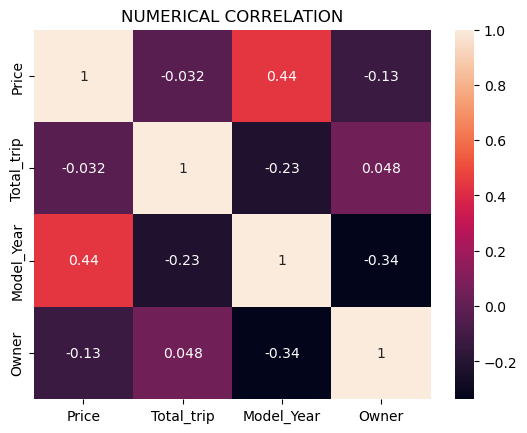

In [89]:
#for numerical correlation
#heatmap
sns.heatmap(df[['Price','Total_trip','Model_Year','Owner']].corr(), annot=True)
plt.title("NUMERICAL CORRELATION")
plt.show()

In [87]:
df['Brand'] = df['Car_Name'].str.split().str[0]
df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10)


Brand
land             6.262500e+06
jaguar           3.722500e+06
bmw              3.559286e+06
mercedes-benz    3.339545e+06
audi             2.823000e+06
volvo            2.750000e+06
mini             2.135500e+06
jeep             1.951667e+06
toyota           1.556704e+06
force            1.200000e+06
Name: Price, dtype: float64